<a href="https://colab.research.google.com/github/sofiiamyshelova-prog/python_for_ds_tasks/blob/main/Copy_of_HW_NLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [1]:
import pandas as pd

# Завантажуємо дані
df = pd.read_csv('/content/tweet_sentiment_train.csv.zip')

# Перші 5 рядків
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [2]:
print(f'Кількість записів: {df.shape[0]}')
print(f'Кількість колонок: {df.shape[1]}')

Кількість записів: 27481
Кількість колонок: 4


In [3]:
df.dtypes

,0
textID,object
text,object
selected_text,object
sentiment,object


In [4]:
df.isnull().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0


In [5]:
df = df.dropna()

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [6]:
print('Класи:', df['sentiment'].unique())

# Кількість об'єктів кожного класу
print('\nРозподіл класів:')
print(df['sentiment'].value_counts())

Класи: ['neutral' 'negative' 'positive']

Розподіл класів:
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64


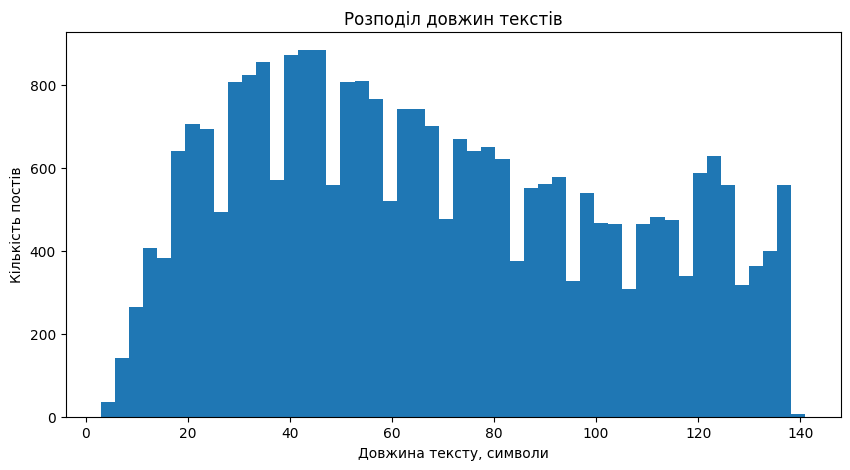

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

df['text_length'] = df['text'].str.len()
plt.hist(df['text_length'], bins=50)

plt.title('Розподіл довжин текстів')
plt.xlabel('Довжина тексту, символи')
plt.ylabel('Кількість постів')
plt.show()

Найбільше постів довжиною приблизно 40, також різко збільшується кількість постів довжиною приблизно 125.
Максимальна кількість 140.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [8]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer('english')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [9]:
def preprocess_text(text):
    # Переводимо в нижній регістр
    text = text.lower()

    # Замінюємо зацензурені слова на спеціальний токен
    text = text.replace('***', 'censored')

    # Токенізація
    tokens = word_tokenize(text)

    # Залишаємо тільки слова
    tokens = [
        word for word in tokens
        if word.isalpha()
    ]

    # Видаляємо stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Стеммінг
    tokens = [
        stemmer.stem(word)
        for word in tokens
    ]

    return tokens

In [10]:
text_example = df['selected_text'].iloc[0]

print('До обробки:')
print(text_example)

print('\nПісля обробки:')
print(preprocess_text(text_example))

До обробки:
I`d have responded, if I were going

Після обробки:
['respond', 'go']


In [12]:
df['processed_text'] = df['selected_text'].apply(
    lambda x: ' '.join(preprocess_text(x))
)

In [13]:
df[['selected_text', 'processed_text']].head()

#мені не подобається, як перетворився текст. В деяких випадках він змінить свій клас, бо видалились "погані" слова


,selected_text,processed_text
0,"I`d have responded, if I were going",respond go
1,Sooo SAD,sooo sad
2,bullying me,bulli
3,leave me alone,leav alon
4,"Sons of ****,",son censor


In [14]:
all_words = ' '.join(df['processed_text']).split()

print('Кількість токенів:', len(all_words))
print('Кількість унікальних слів:', len(set(all_words)))

Кількість токенів: 107251
Кількість унікальних слів: 12547


In [15]:
from collections import Counter

MAX_FEATURES = 5000 #обмежимось 5000 слів з 12541. Це слова, які зустрічаються білтше 15 разів

word_counts = Counter(all_words)

word_counts.most_common(20)

[('go', 1298),
 ('good', 1267),
 ('day', 1242),
 ('love', 1184),
 ('get', 1044),
 ('happi', 865),
 ('work', 856),
 ('like', 852),
 ('miss', 801),
 ('thank', 769),
 ('got', 670),
 ('censor', 635),
 ('time', 624),
 ('one', 586),
 ('today', 583),
 ('want', 570),
 ('lol', 566),
 ('hope', 551),
 ('feel', 537),
 ('u', 532)]

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    max_features=MAX_FEATURES
)

X = vectorizer.fit_transform(df['processed_text'])

In [17]:
print('Розмір матриці:', X.shape)

Розмір матриці: (27480, 5000)


### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [18]:
X = vectorizer.fit_transform(df['processed_text'])
y = df['sentiment']

In [19]:
from sklearn.model_selection import train_test_split

# Індекси всіх спостережень
indices = range(len(df))

# Розділяємо індекси на train та test
train, test= train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Формуємо набори даних
X_train_bow = X[train]
X_test_bow = X[test]

y_train = y.iloc[train]
y_test = y.iloc[test]

print('Train:', X_train_bow.shape)
print('Test:', X_test_bow.shape)

Train: (21984, 5000)
Test: (5496, 5000)


In [20]:
# Логістична регресія

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_bow, y_train)

y_pred_lr = lr_model.predict(X_test_bow)

print('Accuracy:', accuracy_score(y_test, y_pred_lr))

print('\nClassification report:')
print(classification_report(y_test, y_pred_lr))

print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.8009461426491994

Classification report:
              precision    recall  f1-score   support

    negative       0.75      0.79      0.77      1556
     neutral       0.81      0.79      0.80      2223
    positive       0.84      0.83      0.83      1717

    accuracy                           0.80      5496
   macro avg       0.80      0.80      0.80      5496
weighted avg       0.80      0.80      0.80      5496


Confusion matrix:
[[1235  233   88]
 [ 299 1748  176]
 [ 114  184 1419]]


In [21]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=20,
    random_state=42
)

dt_model.fit(X_train_bow, y_train)

y_pred_dt = dt_model.predict(X_test_bow)

print('Accuracy:', accuracy_score(y_test, y_pred_dt))

print('\nClassification report:')
print(classification_report(y_test, y_pred_dt))

print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.5958879184861717

Classification report:
              precision    recall  f1-score   support

    negative       0.83      0.29      0.43      1556
     neutral       0.51      0.90      0.65      2223
    positive       0.82      0.48      0.60      1717

    accuracy                           0.60      5496
   macro avg       0.72      0.56      0.56      5496
weighted avg       0.69      0.60      0.57      5496


Confusion matrix:
[[ 449 1062   45]
 [  80 2006  137]
 [  15  882  820]]


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_bow, y_train)

y_pred_rf = rf_model.predict(X_test_bow)

print('Accuracy:', accuracy_score(y_test, y_pred_rf))

print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7729257641921398

Classification report:
              precision    recall  f1-score   support

    negative       0.72      0.77      0.75      1556
     neutral       0.80      0.73      0.76      2223
    positive       0.79      0.83      0.81      1717

    accuracy                           0.77      5496
   macro avg       0.77      0.78      0.77      5496
weighted avg       0.77      0.77      0.77      5496


Confusion matrix:
[[1199  245  112]
 [ 330 1625  268]
 [ 127  166 1424]]


Найкраще спрацювала логістична регресія Accuracy: 0.80

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [23]:
# Назви токенів
feature_names = vectorizer.get_feature_names_out()

# Коефіцієнти Logistic Regression
coefficients = lr_model.coef_

print('Кількість ознак:', len(feature_names))
print('Розмір coef:', coefficients.shape)
print('Класи:', lr_model.classes_)

Кількість ознак: 5000
Розмір coef: (3, 5000)
Класи: ['negative' 'neutral' 'positive']


In [24]:
for i, class_name in enumerate(lr_model.classes_):

    coef = coefficients[i]

    # Індекси 15 найбільших коефіцієнтів
    top_positive = coef.argsort()[-15:][::-1]

    # Індекси 15 найменших коефіцієнтів
    top_negative = coef.argsort()[:15]

    print(f'\n===== {class_name.upper()} =====')

    print('\nНайбільш характерні слова:')
    for idx in top_positive:
        print(feature_names[idx], round(coef[idx], 3))

    print('\nНайменш характерні слова:')
    for idx in top_negative:
        print(feature_names[idx], round(coef[idx], 3))


===== NEGATIVE =====

Найбільш характерні слова:
sad 2.368
suck 2.34
fail 2.317
hate 2.232
bore 2.14
sorri 2.08
miss 2.047
stupid 2.031
wors 1.927
worst 1.915
wtf 1.862
sick 1.849
hurt 1.839
tire 1.826
unfortun 1.796

Найменш характерні слова:
love -2.616
glad -2.524
awesom -2.514
thank -2.252
hope -2.009
welcom -1.906
beauti -1.894
amaz -1.88
lol -1.803
goodnight -1.781
better -1.773
fine -1.717
great -1.71
haha -1.65
smile -1.616

===== NEUTRAL =====

Найбільш характерні слова:
http 2.532
relat 1.745
download 1.688
goin 1.651
woke 1.631
yeah 1.599
differ 1.512
shoutout 1.504
hello 1.497
watchin 1.483
tour 1.482
nope 1.469
certain 1.449
hey 1.432
watch 1.399

Найменш характерні слова:
cheaper -1.327
relax -1.289
luv -1.235
product -1.216
incred -1.205
nigh -1.184
wtf -1.136
stole -1.126
inspir -1.118
thrill -1.114
soldier -1.105
wors -1.095
delici -1.095
annoy -1.092
wreck -1.077

===== POSITIVE =====

Найбільш характерні слова:
love 2.667
awesom 2.526
glad 2.468
thank 2.422
amaz 2.4

Дуже логічна закономірність для позитивного і негативного класу. Нейтральний важче визначити чітко за словами, бо він десь між ними


### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000
)

# Векторизація тих самих оброблених текстів
X_tfidf = tfidf_vectorizer.fit_transform(df['processed_text'])

print('Розмір TF-IDF матриці:', X_tfidf.shape)

Розмір TF-IDF матриці: (27480, 5000)


In [26]:
df['processed_text'] = df['text'].apply(
    lambda x: ' '.join(preprocess_text(x))
)

In [27]:
X_train_tfidf = X_tfidf[train]
X_test_tfidf = X_tfidf[test]

y_train = y.iloc[train]
y_test = y.iloc[test]

print('Train:', X_train_tfidf.shape)
print('Test:', X_test_tfidf.shape)

Train: (21984, 5000)
Test: (5496, 5000)


In [28]:
lr_tfidf = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)

print('Accuracy:', accuracy_score(y_test, y_pred_tfidf))

print('\nClassification report:')
print(classification_report(y_test, y_pred_tfidf))

print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred_tfidf))

Accuracy: 0.8014919941775837

Classification report:
              precision    recall  f1-score   support

    negative       0.78      0.75      0.76      1556
     neutral       0.77      0.84      0.80      2223
    positive       0.88      0.80      0.83      1717

    accuracy                           0.80      5496
   macro avg       0.81      0.80      0.80      5496
weighted avg       0.81      0.80      0.80      5496


Confusion matrix:
[[1163  327   66]
 [ 223 1876  124]
 [ 102  249 1366]]


Трохи краща точність порівняно з BoW

BoW Accuracy: 0.8009
TF-IDF Accuracy: 0.8015

In [29]:
print('===== BAG OF WORDS =====')
print(classification_report(y_test, y_pred_lr))

print('===== TF-IDF =====')
print(classification_report(y_test, y_pred_tfidf))

===== BAG OF WORDS =====
              precision    recall  f1-score   support

    negative       0.75      0.79      0.77      1556
     neutral       0.81      0.79      0.80      2223
    positive       0.84      0.83      0.83      1717

    accuracy                           0.80      5496
   macro avg       0.80      0.80      0.80      5496
weighted avg       0.80      0.80      0.80      5496

===== TF-IDF =====
              precision    recall  f1-score   support

    negative       0.78      0.75      0.76      1556
     neutral       0.77      0.84      0.80      2223
    positive       0.88      0.80      0.83      1717

    accuracy                           0.80      5496
   macro avg       0.81      0.80      0.80      5496
weighted avg       0.81      0.80      0.80      5496



In [30]:
# Як впливають слова

feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()

coefficients_tfidf = lr_tfidf.coef_

print('Кількість ознак:', len(feature_names_tfidf))
print('Розмір coef:', coefficients_tfidf.shape)
print('Класи:', lr_tfidf.classes_)

Кількість ознак: 5000
Розмір coef: (3, 5000)
Класи: ['negative' 'neutral' 'positive']


In [31]:
for i, class_name in enumerate(lr_model.classes_):

    coef = coefficients_tfidf[i]

    # Індекси 15 найбільших коефіцієнтів
    top_positive = coef.argsort()[-15:][::-1]

    # Індекси 15 найменших коефіцієнтів
    top_negative = coef.argsort()[:15]

    print(f'\n===== {class_name.upper()} =====')

    print('\nНайбільш характерні слова:')
    for idx in top_positive:
        print(feature_names[idx], round(coef[idx], 3))

    print('\nНайменш характерні слова:')
    for idx in top_negative:
        print(feature_names[idx], round(coef[idx], 3))


===== NEGATIVE =====

Найбільш характерні слова:
sad 3.333
miss 3.269
hate 3.1
suck 3.058
fail 2.807
bore 2.746
sorri 2.705
stupid 2.591
hurt 2.463
sick 2.332
poor 2.328
tire 2.191
censor 2.176
worst 2.16
lost 2.048

Найменш характерні слова:
love -3.78
lol -3.317
thank -3.118
hope -2.724
awesom -2.597
glad -2.552
haha -2.535
http -2.426
better -2.362
morn -2.288
great -2.0
amaz -1.959
wait -1.954
yay -1.932
welcom -1.873

===== NEUTRAL =====

Найбільш характерні слова:
http 4.177
watch 2.476
yeah 2.439
know 2.047
yet 2.017
hour 1.991
check 1.961
goin 1.902
hey 1.888
woke 1.887
home 1.808
tho 1.804
say 1.803
lol 1.795
follow 1.779

Найменш характерні слова:
happi -2.374
good -2.142
nice -1.589
fun -1.579
fail -1.503
stupid -1.489
funni -1.444
excit -1.421
great -1.405
hurt -1.364
relax -1.322
amaz -1.312
worri -1.293
perfect -1.276
delici -1.249

===== POSITIVE =====

Найбільш характерні слова:
love 4.707
thank 4.047
great 3.406
awesom 3.333
amaz 3.271
happi 3.252
hope 3.113
glad 3.07

In [32]:
def get_top_words(model, vectorizer, n=15):
    feature_names = vectorizer.get_feature_names_out()

    result = {}

    for i, class_name in enumerate(model.classes_):
        coef = model.coef_[i]

        top_indices = coef.argsort()[-n:][::-1]

        result[class_name] = pd.DataFrame({
            'word': feature_names[top_indices],
            'coefficient': coef[top_indices]
        })

    return result

bow_words = get_top_words(lr_model, vectorizer)

tfidf_words = get_top_words(lr_tfidf, tfidf_vectorizer)

In [33]:
print('BoW — positive')
display(bow_words['positive'])

print('TF-IDF — positive')
display(tfidf_words['positive'])

BoW — positive


,word,coefficient
0,love,2.666792
1,awesom,2.526087
2,glad,2.467826
3,thank,2.422237
4,amaz,2.414844
5,happi,2.163476
6,cute,2.144826
7,great,2.116651
8,fantast,2.115331
9,luv,2.089708


TF-IDF — positive


,word,coefficient
0,love,4.706845
1,thank,4.047323
2,great,3.405824
3,awesom,3.332643
4,amaz,3.271270
5,happi,3.251636
6,hope,3.113369
7,glad,3.074904
8,nice,2.839686
9,good,2.824712


Для фінальної імплементації я б обрала TF-IDF, оскільки ця векторизація дала трохи кращий результат за основною метрикою та краще враховує інформативність окремих слів.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [58]:
errors = df.iloc[test].copy()

errors['predicted_sentiment'] = y_pred_tfidf

errors = errors[
    errors['sentiment'] != errors['predicted_sentiment']
]

errors[['text', 'sentiment', 'predicted_sentiment']].head(50)

,text,sentiment,predicted_sentiment
19360,Having a wonderful piece of cake for lunch - w...,positive,neutral
24967,"Don`t worry, you`ll get your stamina back soo...",positive,negative
17484,"Awww, *hugs* I wish I could help.",negative,positive
7936,2 hours after teleconference. but can`t go bac...,negative,neutral
10247,Youtube isn`t working...and I wanted to watch ...,negative,neutral
3704,**** Frat - that`s too bad... Should be a go...,neutral,positive
18944,_Jamie I guess ! I was really suprised..,positive,neutral
27112,i want so bad to go to the mcfly`s concert,positive,neutral
16611,I just KNEW you`d get that!,positive,neutral
7069,babysitting kids who won`t let me play wii wit...,negative,neutral


1. модель часто плутає neutral з positive або negative

TF-IDF працює переважно на основі окремих слів та їхньої ваги, тому йому складно визначити загальну емоційну спрямованість короткого повідомлення

2. сленг, скорочення та помилки в написанні

cnt, lmao, luv, ain't, Fakin', bt, u, wanna

модель погано ідентифікує такі слова, бо вони не обєднуються зі своїми синонімами, що написані літературно

3. Модель погано розуміє контекст і заперечення


Покращення

1. Покращити preprocessing тексту.
Нормалізувати сленг і скорочення (luv → love, u → you тощо), враховувати біграми/триграми та не видаляти слова, які важливі для заперечень (not, don't, never).

2. Використати модель, яка краще враховує контекст.
Наприклад, word embeddings. Вони краще працюють із контекстом, запереченнями, сленгом та різними значеннями одного слова залежно від контексту.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model